In [1]:
%run -i ../python_scripts/nb_setup.py

GPU Available: False


#### Example of a simulated dataset with $\beta$ distributions mixture

In [2]:
df = simulate_sgp_dataset(n=10000)
df

,y_true,y_pred,kappa
0,0,0.0,0.994084
1,1,1.0,0.972204
2,0,0.0,0.763839
3,0,0.0,0.977806
4,0,1.0,0.380255
...,...,...,...
9995,1,1.0,0.837544
9996,0,0.0,0.956362
9997,1,1.0,0.758735
9998,1,1.0,0.819119


#### The simulation should verify monotonicity

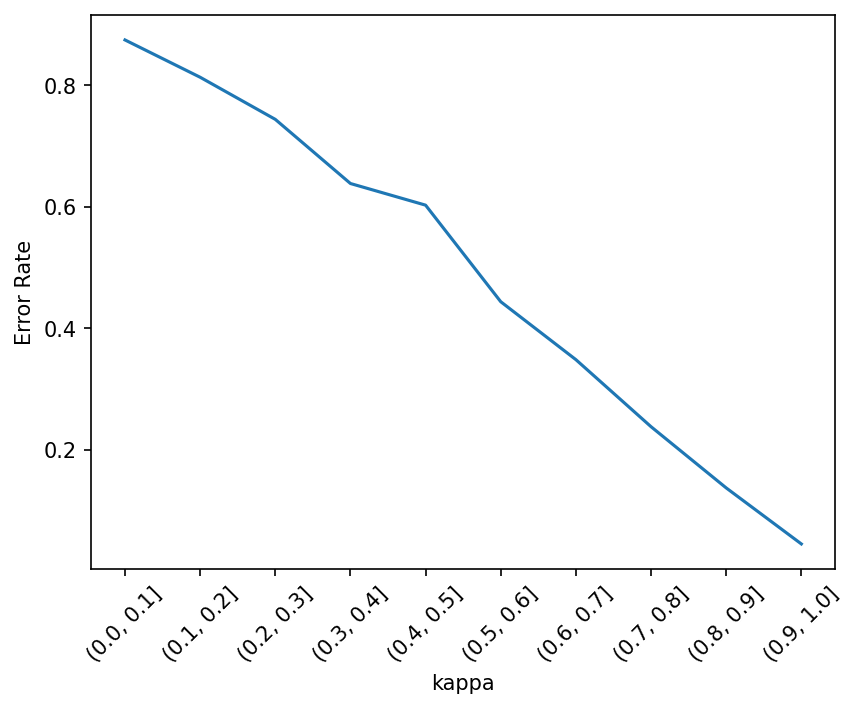

In [3]:
mistakes_by_SR = df.groupby(pd.cut(df["kappa"], bins=np.linspace(0, 1, 11)))[
    "y_true"
].apply(lambda x: (x != df.loc[x.index, "y_pred"]).mean())
plt.plot(mistakes_by_SR.index.astype(str), mistakes_by_SR)
plt.xlabel("kappa")
plt.ylabel("Error Rate")
plt.xticks(rotation=45)
plt.show()

### Evolution of runtime with sample size $n$

In [4]:
n_seed = 20
samples_sizes = [10000 * i for i in range(1, 11)]

In [5]:
dicos = []

for n in samples_sizes:
    times = [
        runtime(simulate_sgp_dataset(n=n, seed=seed), theta_min=0, theta_max=1)
        for seed in range(n_seed)
    ]
    quantiles = [np.quantile(times, q=q) for q in [0.25, 0.5, 0.75]]
    dicos.append({"Search mode": "Dichotomy", "n": n, "Runtime quantiles": quantiles})

    for k2 in [30, 50, 70, 90]:
        times = [
            runtime(
                simulate_sgp_dataset(n=n, seed=seed),
                mode="greedy",
                k2=k2,
                theta_min=0,
                theta_max=1,
            )
            for seed in range(n_seed)
        ]
        quantiles = [np.quantile(times, q=q) for q in [0.25, 0.5, 0.75]]
        dicos.append(
            {
                "Search mode": "Greedy_" + str(k2) + "_steps",
                "n": n,
                "Runtime quantiles": quantiles,
            }
        )

In [6]:
times = pd.DataFrame(dicos)
times

,Search mode,n,Runtime quantiles
0,Dichotomy,10000,"[0.0, 0.0, 0.0]"
1,Greedy_30_steps,10000,"[10.0, 10.0, 10.0]"
2,Greedy_50_steps,10000,"[16.0, 16.0, 16.0]"
3,Greedy_70_steps,10000,"[22.0, 23.0, 23.0]"
4,Greedy_90_steps,10000,"[29.0, 29.0, 30.0]"
5,Dichotomy,20000,"[1.0, 1.0, 1.0]"
6,Greedy_30_steps,20000,"[21.0, 22.0, 22.0]"
7,Greedy_50_steps,20000,"[33.0, 34.0, 35.0]"
8,Greedy_70_steps,20000,"[47.0, 48.5, 50.0]"
9,Greedy_90_steps,20000,"[60.75, 62.0, 63.0]"


In [7]:
pickle.dump(times, open("exec_times_res", "wb"))

#### Plotting execution runtimes

In [8]:
import ast

# --- make sure q1/median/q3 exist as numeric columns ---
if (
    "median" not in times.columns
    or "q1" not in times.columns
    or "q3" not in times.columns
):
    # If quantiles are strings like "[low, med, high]", convert to lists
    if isinstance(times["Runtime quantiles"].iloc[0], str):
        times = times.copy()
        times["Runtime quantiles"] = times["Runtime quantiles"].apply(ast.literal_eval)

    # Split into columns
    times["q1"] = times["Runtime quantiles"].apply(lambda x: x[0])
    times["median"] = times["Runtime quantiles"].apply(lambda x: x[1])
    times["q3"] = times["Runtime quantiles"].apply(lambda x: x[2])

    # Ensure numeric dtypes (in case of strings)
    for col in ["n", "q1", "median", "q3"]:
        times[col] = pd.to_numeric(times[col], errors="coerce")

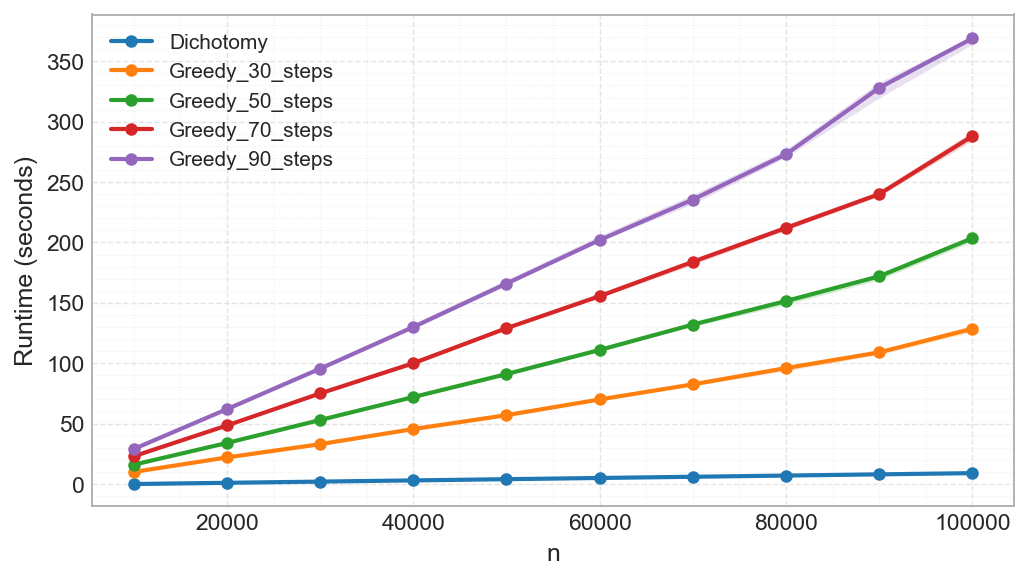

In [9]:
# --- STYLE
rc = {
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "axes.linewidth": 1.0,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.frameon": True,
    "legend.framealpha": 0.9,
    "legend.facecolor": "white",
    "legend.edgecolor": "#D0D0D0",
    "grid.alpha": 0.4,
    "lines.linewidth": 2.0,
}
with plt.rc_context(rc), plt.style.context("seaborn-v0_8-whitegrid"):
    fig, ax = plt.subplots(figsize=(7, 4))

    for mode, group in times.groupby("Search mode"):
        group = group.sort_values("n")
        ax.plot(
            group["n"],
            group["median"],
            label=mode,
            marker="o",
            markersize=5,
            linewidth=2,
        )
        ax.fill_between(group["n"], group["q1"], group["q3"], alpha=0.2)

    # Labels and legend
    ax.set_xlabel("n")
    ax.set_ylabel("Runtime (seconds)")
    ax.legend(loc="best", fontsize=10)

    # Spines, ticks, grid
    for spine in ax.spines.values():
        spine.set_color("#B0B0B0")
        spine.set_linewidth(0.9)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    ax.grid(True, which="major", linestyle="--", linewidth=0.7, alpha=0.5)
    ax.grid(True, which="minor", linestyle=":", linewidth=0.5, alpha=0.3)

    plt.tight_layout()
    plt.show()